# Logistic Regression Model Training & Tuning

This notebook trains a Logistic Regression classifier on the linearized session windows data using all available numerical features.
The target is rating, so we scale the features before fitting the model.

We tune Logistic Regression with a single static validation split (PredefinedSplit), then compare a few simple logistic regression setups.

In [1]:
import sys
from pathlib import Path

# Add project root directory to path for imports
sys.path.append(str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from scripts.evaluation_metrics import evaluate_model, compare_models

## Load and Preprocess Data

We load the processed session-window data, remove identifier/leakage columns, split into train/test sets, and scale the numeric features.

In [2]:
data_path = Path("../../data/processed/linearized_session_windows.csv")
df = pd.read_csv(data_path).dropna(subset=["rating"])
df["rating"] = df["rating"].astype(int)

# Drop rating itself plus identifier/leakage columns. focus_score is the old target, so it must not be used as a feature.
cols_to_drop = [
    "focus_score",
    "rating",
    "segment_id",
    "session_id",
    "source",
    "location_id",
    "segment_start",
    "segment_end",
]

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).select_dtypes(include=[np.number])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (9081, 42)
Test set shape: (2271, 42)


## Data Distribution

A quick check of the rating distribution before training.

,Train,Test
rating,,
1,167,42
2,1352,338
3,5258,1315
4,1327,332
5,977,244


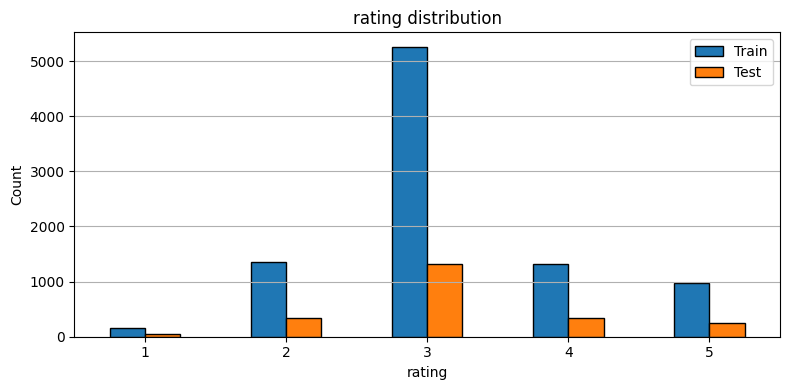

In [3]:
class_counts = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index(),
}).fillna(0).astype(int)

display(class_counts)

class_counts.plot(kind="bar", figsize=(8, 4), edgecolor="black")
plt.title("rating distribution")
plt.xlabel("rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning via Randomized Search

We use a static validation split (holdout set) rather than K-Fold cross-validation to save compute time and keep the setup aligned with the other model notebooks.

In [4]:
param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
}

# Split training data to create a single static validation set (holdout)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Create a PredefinedSplit where training is -1 and validation is 0
split_index = [-1] * len(X_tr) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

# Combine train and validation sets back together for fit()
X_tune = pd.concat([X_tr, X_val])
y_tune = pd.concat([y_tr, y_val])

base_model = LogisticRegression(max_iter=2000, random_state=42)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=pds,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_tune, y_tune)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Validation Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'class_weight': None, 'C': 100}
Best Validation Accuracy: 0.6329


## Evaluate Best Model

We evaluate the optimized Logistic Regression model on the test split of the training dataset.


--- Train Metrics ---
Accuracy:  0.6364
Precision (weighted): 0.6144
Recall (weighted):    0.6364
F1 Score (weighted):  0.5767

--- Test/Validation Metrics ---
Accuracy:  0.6248
Precision (weighted): 0.5991
Recall (weighted):    0.6248
F1 Score (weighted):  0.5630



--- Model Coefficients (Top 20 by Absolute Value) ---
temperature_mean     6.658110
meanTemp             6.658110
cluster              2.975619
light_mean          -1.705450
noise_mean           1.037423
temperature_std     -0.848894
light_std           -0.820751
co2_std              0.641488
co2_range           -0.587036
noise_range         -0.565945
light_count          0.561875
co2_count            0.561875
noise_count          0.561875
humidity_count       0.561875
n_readings           0.561875
temperature_count    0.561875
noise_std            0.549313
light_max            0.510220
humidity_std         0.486821
temperature_min     -0.471846
dtype: float64


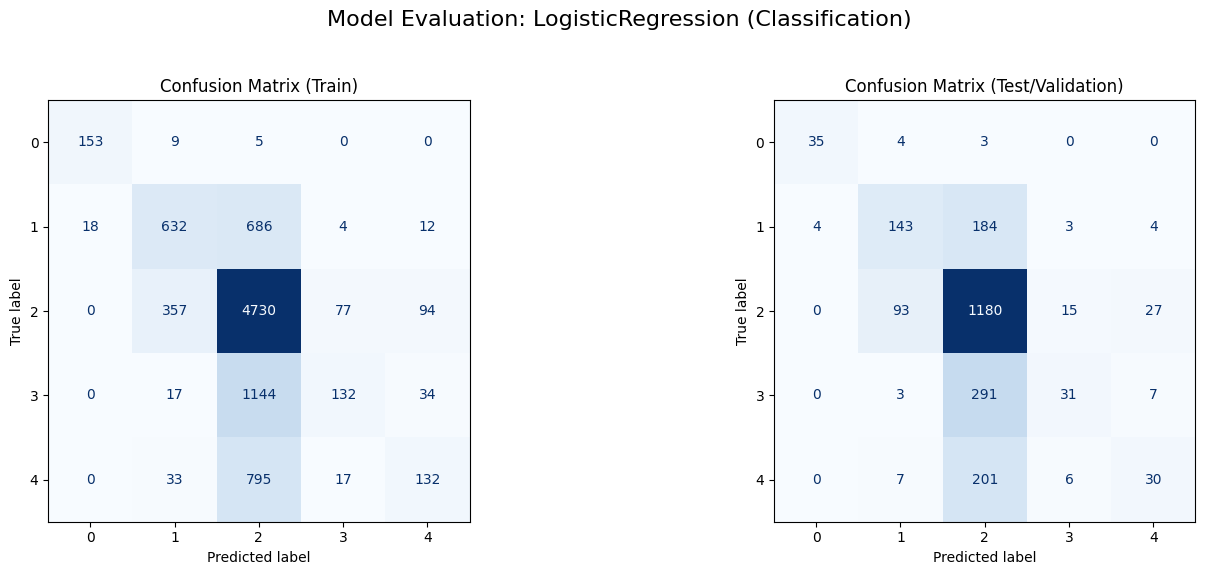

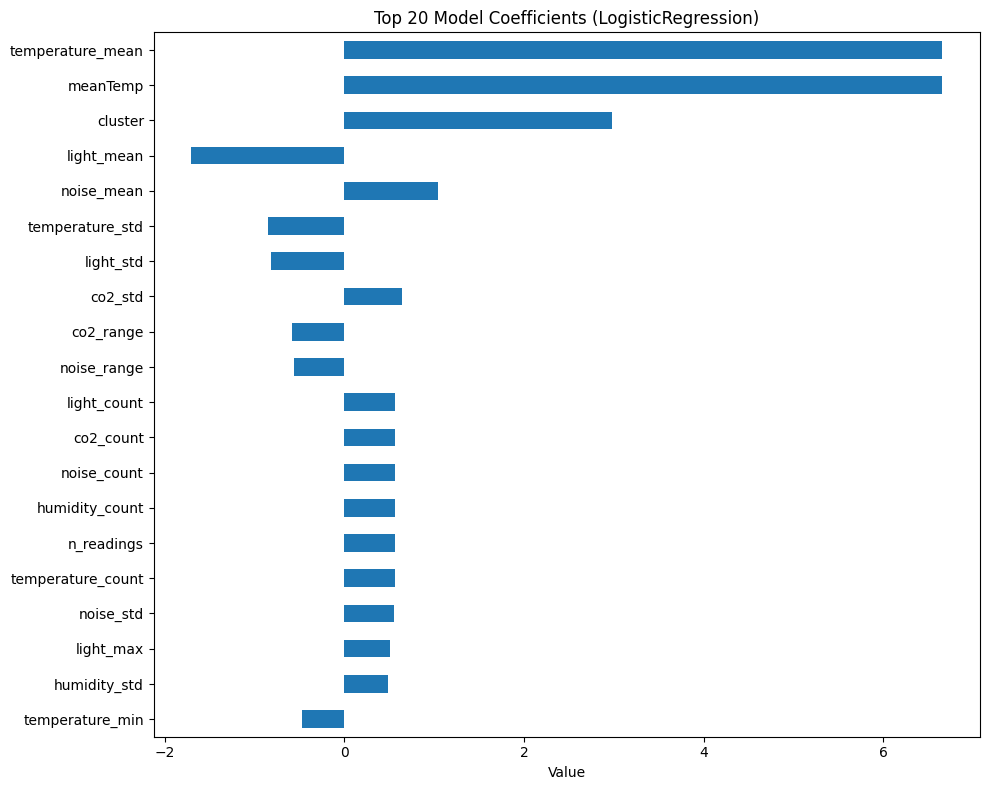

In [5]:
best_model = random_search.best_estimator_
figures = evaluate_model(best_model, X_train_scaled, X_test_scaled, y_train, y_test, is_classification=True)

## Evaluate on Real Production Data

We load the real session data exported from the database, scale it using the same scaler fitted on our training data, and evaluate our tuned model on it.

In [6]:
# Path to real data generated from the production database
real_data_path = Path("../../data/real/linearized_sessions_with_target.csv")

if real_data_path.exists() and real_data_path.stat().st_size > 0:
    try:
        real_df = pd.read_csv(real_data_path).dropna(subset=["rating"])
        if not real_df.empty:
            # Select features (must match the same feature columns used in training)
            X_real = real_df[X_train.columns]
            y_real = real_df["rating"].astype(int)

            # Scale real features using the same scaler fitted on training data
            X_real_scaled = pd.DataFrame(
                scaler.transform(X_real),
                columns=X_real.columns,
                index=X_real.index,
            )

            print(f"Loaded {len(real_df)} real sessions for evaluation.")
            figs_real = evaluate_model(best_model, X_train_scaled, X_real_scaled, y_train, y_real, is_classification=True)
        else:
            print("Real data CSV is empty.")
    except pd.errors.EmptyDataError:
        print("Real data CSV is empty.")
    except Exception as e:
        print(f"Could not load or evaluate real data: {e}")
else:
    print(f"No real data available for testing at: {real_data_path}")

Real data CSV is empty.


## Accuracy Comparison

This compares the different logistic regression setups tested in this notebook on the same train/test split.

,Train Accuracy,Test Accuracy,Test Macro F1
Model,,,
LogReg tuned,0.6361,0.6248,0.4893
LogReg default,0.6359,0.6244,0.4742
Majority Baseline,0.5790,0.5790,0.1467
LogReg balanced,0.4835,0.4685,0.4917


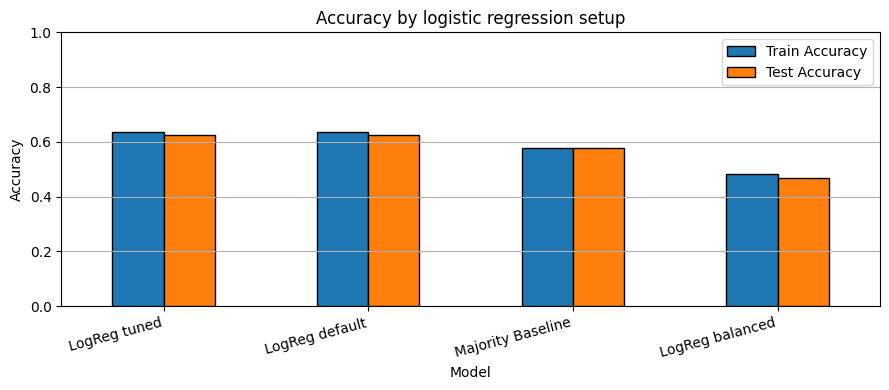

In [7]:
models = {
    "Majority Baseline": DummyClassifier(strategy="most_frequent"),
    "LogReg default": LogisticRegression(max_iter=2000, random_state=42),
    "LogReg balanced": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "LogReg tuned": best_model,
}

accuracy_comparison = compare_models(
    models, X_train_scaled, X_test_scaled, y_train, y_test,
    plot_title="Accuracy by logistic regression setup"
)

## Conclusion

Logistic Regression is a simple linear baseline for predicting rating from the environmental sensor features.

The tuned model is easy to interpret and fast to train, but the accuracy comparison shows that class imbalance matters. The majority baseline can look strong on accuracy because rating 3 appears often, so macro F1 is useful alongside accuracy.

The confusion matrices show which rating classes are predicted well and where the model mixes up neighboring scores.